# Multi-Task Loss Weighting Ablation

In [1]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
import torch

from kkbox import config as kkbox_config
from kkbox.data import columns_from_manifest, load_splits, make_loader, stratified_subsample
from kkbox.determinism import seed_everything
from kkbox.models import build_model
from kkbox.train import PCGrad, eval_metrics, train_model, train_pcgrad, train_uncertainty_weighted

CFG = kkbox_config.load_config()
PROCESSED_DIR = kkbox_config.abspath(CFG, CFG["paths"]["processed_dir"])
# KKBOX_MODELS_DIR/KKBOX_RESULTS_DIR let `make smoke` redirect checkpoint/results
# writes to an isolated /tmp location instead of overwriting the real committed
# artifacts - nbconvert's --output-dir only redirects where the *executed
# notebook file* is saved, it does NOT change cwd-relative paths used inside cells.
MODELS_DIR = os.environ.get("KKBOX_MODELS_DIR", kkbox_config.abspath(CFG, CFG["paths"]["models_dir"]))
RESULTS_DIR = os.environ.get("KKBOX_RESULTS_DIR", kkbox_config.abspath(CFG, CFG["paths"]["results_dir"]))
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
# Set via env var for `make smoke` (2% stratified subsample); unset for a real run.
SUBSAMPLE_FRAC = float(os.environ["KKBOX_SUBSAMPLE_FRAC"]) if "KKBOX_SUBSAMPLE_FRAC" in os.environ else None

with open(os.path.join(PROCESSED_DIR, "feature_manifest.json")) as f:
    manifest = json.load(f)

CAT_COLS, NUM_COLS, CARDINALITIES, EMBED_DIMS = columns_from_manifest(manifest)

## Dataset, FM layer, model, and shared training utilities

Imported from `kkbox.data`/`kkbox.models`/`kkbox.train` (Phase 0 refactor - previously redefined inline in every notebook, including `05`'s own separate near-duplicate training loop, now consolidated into `kkbox.train.train_model`).

In [3]:
splits = load_splits(PROCESSED_DIR)
train_df, val_df, test_df = splits["train"], splits["val"], splits["test"]

if SUBSAMPLE_FRAC is not None:
    train_df = stratified_subsample(train_df, SUBSAMPLE_FRAC)
    val_df = stratified_subsample(val_df, SUBSAMPLE_FRAC)
    test_df = stratified_subsample(test_df, SUBSAMPLE_FRAC)
    print(f"SUBSAMPLE_FRAC={SUBSAMPLE_FRAC} applied (stratified by is_churn)")

train_loader = make_loader(train_df, CAT_COLS, NUM_COLS, CFG["training"]["batch_size"],
                            shuffle=True, seed=CFG["seeds"]["default"])
val_loader = make_loader(val_df, CAT_COLS, NUM_COLS, CFG["training"]["batch_size"], shuffle=False)
test_loader = make_loader(test_df, CAT_COLS, NUM_COLS, CFG["training"]["batch_size"], shuffle=False)

pos_weight = torch.tensor((train_df["is_churn"] == 0).sum() / (train_df["is_churn"] == 1).sum())
print(f"pos_weight: {pos_weight.item():.2f}")

## Exp-3, Exp-4, Exp-5: fixed loss weights

Combined loss `Total_Loss = lambda_churn * BCE + lambda_ltv * MSE` (Section 4.4). Same training loop as `04_Training_Baselines.ipynb`, just with both lambdas nonzero.

In [5]:
FIXED_CONFIGS = {
    "exp3_fixed_5050": (0.5, 0.5),
    "exp4_churn_dominant": (0.7, 0.3),
    "exp5_ltv_dominant": (0.3, 0.7),
}

fixed_models, fixed_histories = {}, {}
for name, (lc, ll) in FIXED_CONFIGS.items():
    print(f"\n=== {name} (lambda_churn={lc}, lambda_ltv={ll}) ===")
    seed_everything(CFG["seeds"]["default"])
    ckpt_path = os.path.join(MODELS_DIR, f"{name}.pt")
    model = build_model(CARDINALITIES, EMBED_DIMS, CAT_COLS, len(NUM_COLS), CFG["model"])
    hist = train_model(model, train_loader, val_loader, lambda_churn=lc, lambda_ltv=ll,
                        pos_weight=pos_weight, train_cfg=CFG["training"], checkpoint_path=ckpt_path)
    hist.to_csv(os.path.join(RESULTS_DIR, f"{name}_history.csv"), index=False)
    model.load_state_dict(torch.load(ckpt_path, weights_only=True))
    fixed_models[name] = model
    fixed_histories[name] = hist


=== exp3_fixed_5050 (lambda_churn=0.5, lambda_ltv=0.5) ===


epoch  0 val_loss=1.7086 val_auc=0.9033 val_rmse_log=1.7915


epoch  1 val_loss=1.6533 val_auc=0.9073 val_rmse_log=1.7616


epoch  2 val_loss=1.6241 val_auc=0.9104 val_rmse_log=1.7458


epoch  3 val_loss=1.5875 val_auc=0.9118 val_rmse_log=1.7252


...

epoch 45 val_loss=1.8912 val_auc=0.9259 val_rmse_log=1.6197


epoch 46 val_loss=1.8863 val_auc=0.9258 val_rmse_log=1.6175


epoch 47 val_loss=1.8997 val_auc=0.9264 val_rmse_log=1.6235


epoch 48 val_loss=1.8900 val_auc=0.9264 val_rmse_log=1.6192


epoch 49 val_loss=1.8897 val_auc=0.9258 val_rmse_log=1.6190


## Exp-6: Uncertainty weighting (Kendall, Gal & Cipolla, 2018)

Learns a per-task log-variance `s = log(sigma^2)` and weights each loss by its learned homoscedastic uncertainty: `L = 0.5*exp(-s)*L_task + 0.5*s`. This is the standard *practical* form used for both tasks here — the paper's exact derivation differs slightly between a Gaussian (regression) and categorical (classification) likelihood, but treating the classification loss the same way as the regression term is the common simplification used in nearly all open implementations, and is what we do below. `log_var_churn` and `log_var_ltv` are optimized jointly with the model in the same Adam optimizer.

In [6]:
seed_everything(CFG["seeds"]["default"])
print("=== exp6_uncertainty ===")
exp6_ckpt = os.path.join(MODELS_DIR, "exp6_uncertainty.pt")
model_exp6, hist_exp6 = train_uncertainty_weighted(
    build_model(CARDINALITIES, EMBED_DIMS, CAT_COLS, len(NUM_COLS), CFG["model"]),
    train_loader, val_loader, CFG["training"], checkpoint_path=exp6_ckpt,
)
hist_exp6.to_csv(os.path.join(RESULTS_DIR, "exp6_history.csv"), index=False)
exp6_ckpt_data = torch.load(exp6_ckpt, weights_only=True)
model_exp6.load_state_dict(exp6_ckpt_data["model"])

=== exp6_uncertainty ===


epoch  0 val_loss=1.2520 val_auc=0.9048 val_rmse_log=1.7924 log_var_churn=-0.542 log_var_ltv=0.291


epoch  1 val_loss=0.9390 val_auc=0.9092 val_rmse_log=1.7587 log_var_churn=-1.003 log_var_ltv=0.553


epoch  2 val_loss=0.7983 val_auc=0.9128 val_rmse_log=1.7437 log_var_churn=-1.342 log_var_ltv=0.762


epoch  3 val_loss=0.7436 val_auc=0.9150 val_rmse_log=1.7302 log_var_churn=-1.529 log_var_ltv=0.914


...

epoch 46 val_loss=0.6120 val_auc=0.9329 val_rmse_log=1.6241 log_var_churn=-1.720 log_var_ltv=1.004


epoch 47 val_loss=0.6143 val_auc=0.9329 val_rmse_log=1.6268 log_var_churn=-1.718 log_var_ltv=1.004


epoch 48 val_loss=0.6124 val_auc=0.9329 val_rmse_log=1.6242 log_var_churn=-1.721 log_var_ltv=1.004


epoch 49 val_loss=0.6097 val_auc=0.9332 val_rmse_log=1.6214 log_var_churn=-1.722 log_var_ltv=1.009


<All keys matched successfully>

## Exp-7: PCGrad (Yu et al., NeurIPS 2020)

Computes each task's gradient separately, projects away the conflicting component (negative cosine similarity) against every *other* task's gradient, then sums the projected gradients before the optimizer step. See the bug-fix note at the top of this notebook for why the implementation below differs from the plan's pseudocode.

In [8]:
seed_everything(CFG["seeds"]["default"])
print("=== exp7_pcgrad ===")
exp7_ckpt = os.path.join(MODELS_DIR, "exp7_pcgrad.pt")
model_exp7, hist_exp7 = train_pcgrad(
    build_model(CARDINALITIES, EMBED_DIMS, CAT_COLS, len(NUM_COLS), CFG["model"]),
    train_loader, val_loader, CFG["training"], checkpoint_path=exp7_ckpt,
)
hist_exp7.to_csv(os.path.join(RESULTS_DIR, "exp7_history.csv"), index=False)
model_exp7.load_state_dict(torch.load(exp7_ckpt, weights_only=True))

=== exp7_pcgrad ===


epoch  0 val_loss=3.4466 val_auc=0.9029 val_rmse_log=1.7996


epoch  1 val_loss=3.2940 val_auc=0.9071 val_rmse_log=1.7580


epoch  2 val_loss=3.2786 val_auc=0.9100 val_rmse_log=1.7543


epoch  3 val_loss=3.1893 val_auc=0.9111 val_rmse_log=1.7291


...

epoch 46 val_loss=2.7903 val_auc=0.9294 val_rmse_log=1.6160


epoch 47 val_loss=2.8040 val_auc=0.9293 val_rmse_log=1.6202


epoch 48 val_loss=2.7946 val_auc=0.9295 val_rmse_log=1.6174


epoch 49 val_loss=2.7932 val_auc=0.9293 val_rmse_log=1.6169


<All keys matched successfully>

## Consolidated results (Section 7.4 Multi-Task Benefit Analysis)

In [9]:
with open(os.path.join(RESULTS_DIR, "baseline_results.json")) as f:
    baseline_results = json.load(f)

all_models = {**fixed_models, "exp6_uncertainty": model_exp6, "exp7_pcgrad": model_exp7}
rows = [
    {"experiment": "exp1_churn_only", "lambda_churn": 1.0, "lambda_ltv": 0.0,
     "test_auc": baseline_results["exp1_churn_only"]["test"]["churn_auc_roc"],
     "test_rmse_raw_twd": None},
    {"experiment": "exp2_ltv_only", "lambda_churn": 0.0, "lambda_ltv": 1.0,
     "test_auc": None,
     "test_rmse_raw_twd": baseline_results["exp2_ltv_only"]["test"]["ltv_rmse_raw_twd"]},
]
for name, model in all_models.items():
    test_auc, test_rmse_log = eval_metrics(model, test_loader)
    lc, ll = FIXED_CONFIGS.get(name, (None, None))
    rows.append({"experiment": name, "lambda_churn": lc, "lambda_ltv": ll,
                  "test_auc": test_auc, "test_rmse_log": test_rmse_log})

results_table = pd.DataFrame(rows)
results_table.to_csv(os.path.join(RESULTS_DIR, "ablation_results_table.csv"), index=False)
results_table

,experiment,lambda_churn,lambda_ltv,test_auc,test_rmse_raw_twd,test_rmse_log
0,exp1_churn_only,1.0,0.0,0.930199,NaN,NaN
1,exp2_ltv_only,0.0,1.0,NaN,154.486404,NaN
2,exp3_fixed_5050,0.5,0.5,0.926904,NaN,1.622609
3,exp4_churn_dominant,0.7,0.3,0.930972,NaN,1.617768
4,exp5_ltv_dominant,0.3,0.7,0.924591,NaN,1.618825
5,exp6_uncertainty,NaN,NaN,0.932113,NaN,1.623054
6,exp7_pcgrad,NaN,NaN,0.928292,NaN,1.618002


## Pareto frontier: churn AUC vs. LTV RMSE

Per Section 6.2's headline-result instruction: plot churn AUC and LTV RMSE for Exp-1 to Exp-5 on the same axes (tracing the frontier), then overlay Exp-6/Exp-7 as starred points. A multi-task variant sitting at or near the frontier (good AUC *and* good RMSE simultaneously) is evidence that principled loss balancing recovers most of the single-task ceiling on both objectives at once.

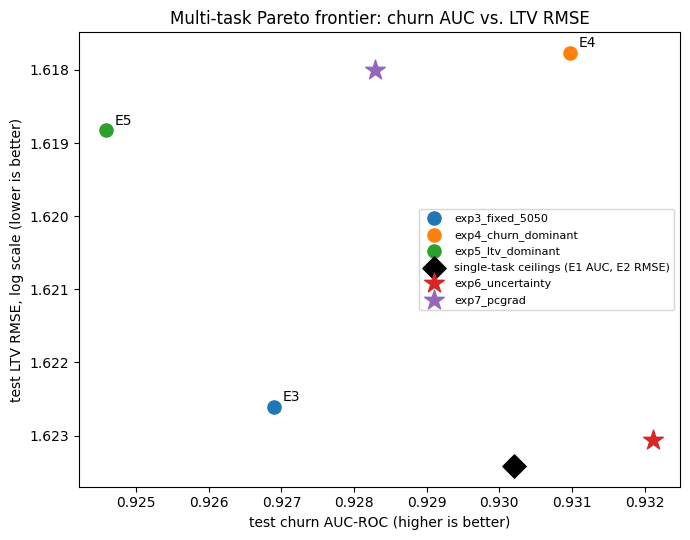

In [10]:
frontier_rows = []
for name, model in {**fixed_models}.items():
    auc, rmse_log = eval_metrics(model, test_loader)
    frontier_rows.append((name, auc, rmse_log))
exp1_auc = baseline_results["exp1_churn_only"]["test"]["churn_auc_roc"]
exp2_rmse_log = baseline_results["exp2_ltv_only"]["test"]["ltv_rmse_log"]

exp6_auc, exp6_rmse = eval_metrics(model_exp6, test_loader)
exp7_auc, exp7_rmse = eval_metrics(model_exp7, test_loader)

fig, ax = plt.subplots(figsize=(7, 5.5))
for name, auc, rmse in frontier_rows:
    ax.scatter(auc, rmse, s=90, label=name)
    ax.annotate(name.replace("exp", "E").split("_")[0], (auc, rmse), textcoords="offset points", xytext=(6, 4))
ax.scatter(exp1_auc, exp2_rmse_log, s=140, marker="D", color="black", label="single-task ceilings (E1 AUC, E2 RMSE)")
ax.scatter(exp6_auc, exp6_rmse, s=220, marker="*", color="tab:red", label="exp6_uncertainty")
ax.scatter(exp7_auc, exp7_rmse, s=220, marker="*", color="tab:purple", label="exp7_pcgrad")
ax.set_xlabel("test churn AUC-ROC (higher is better)")
ax.set_ylabel("test LTV RMSE, log scale (lower is better)")
ax.set_title("Multi-task Pareto frontier: churn AUC vs. LTV RMSE")
ax.legend(fontsize=8, loc="best")
ax.invert_yaxis()  # up-and-right = better on both axes
fig.tight_layout()

## Loss-weighting ablation curves

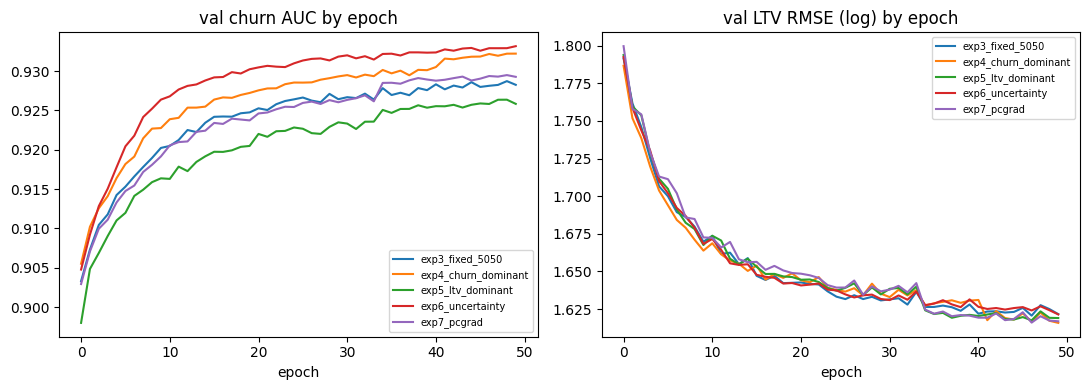

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, hist in {**fixed_histories, "exp6_uncertainty": hist_exp6, "exp7_pcgrad": hist_exp7}.items():
    axes[0].plot(hist["epoch"], hist["val_auc"], label=name)
    axes[1].plot(hist["epoch"], hist["val_rmse_log"], label=name)
axes[0].set_title("val churn AUC by epoch")
axes[1].set_title("val LTV RMSE (log) by epoch")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend(fontsize=7)
fig.tight_layout()

## Summary

In [12]:
mt_rows = [r for r in rows if r["experiment"] not in ("exp1_churn_only", "exp2_ltv_only")]
best_auc_row = max(mt_rows, key=lambda r: r["test_auc"])
best_rmse_row = min(mt_rows, key=lambda r: r["test_rmse_log"])

print(f"Single-task ceilings: churn AUC={exp1_auc:.4f} (Exp-1), LTV RMSE(log)={exp2_rmse_log:.4f} (Exp-2)")
print(f"Best multi-task churn AUC: {best_auc_row['experiment']} ({best_auc_row['test_auc']:.4f}, "
      f"{best_auc_row['test_auc'] - exp1_auc:+.4f} vs. Exp-1 ceiling)")
print(f"Best multi-task LTV RMSE: {best_rmse_row['experiment']} ({best_rmse_row['test_rmse_log']:.4f}, "
      f"{best_rmse_row['test_rmse_log'] - exp2_rmse_log:+.4f} vs. Exp-2 ceiling)")
print(f"\nExp-6 (uncertainty): AUC={exp6_auc:.4f}, RMSE(log)={exp6_rmse:.4f}")
print(f"Exp-7 (PCGrad):      AUC={exp7_auc:.4f}, RMSE(log)={exp7_rmse:.4f}")

Single-task ceilings: churn AUC=0.9302 (Exp-1), LTV RMSE(log)=1.6234 (Exp-2)
Best multi-task churn AUC: exp6_uncertainty (0.9321, +0.0019 vs. Exp-1 ceiling)
Best multi-task LTV RMSE: exp4_churn_dominant (1.6178, -0.0056 vs. Exp-2 ceiling)

Exp-6 (uncertainty): AUC=0.9321, RMSE(log)=1.6231
Exp-7 (PCGrad):      AUC=0.9283, RMSE(log)=1.6180
